In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

#Set a default seaborn style
sns.set_style('whitegrid')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance

import pickle

In [6]:
#read in data
data = pd.read_csv('/home/amybirdee/hobby_projects/attachment_style_prediction/attachment_survey_with_labels.csv')

In [7]:
#drop unwanted columns
data = data.drop(['Unnamed: 0', '__row_id', 'relationship_reflection'], axis = 1)

In [8]:
data.head()

,age,gender,relationship_status,parenting_style,conflict_response,comfort_with_intimacy,fear_of_abandonment,trust_in_others,openness_in_relationships,social_support_perception,relationship_satisfaction,mental_health_status,attachment_style_label
0,45,Male,Single,Authoritative,Compromising,3,1,2,5,5,5,Stable,Dismissive Avoidant
1,31,Female,In a relationship,Authoritative,Passive,2,2,4,1,1,5,Mild Issues,Fearful Avoidant
2,24,Prefer not to say,In a relationship,Permissive,Compromising,4,1,4,1,4,4,Stable,Secure
3,37,Male,Single,NaN,Avoidant,1,5,1,2,5,3,Mild Issues,Fearful Avoidant
4,35,Female,In a relationship,Permissive,Assertive,3,1,5,2,2,5,Mild Issues,Secure


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3000 non-null   int64 
 1   gender                     3000 non-null   object
 2   relationship_status        3000 non-null   object
 3   parenting_style            2415 non-null   object
 4   conflict_response          3000 non-null   object
 5   comfort_with_intimacy      3000 non-null   int64 
 6   fear_of_abandonment        3000 non-null   int64 
 7   trust_in_others            3000 non-null   int64 
 8   openness_in_relationships  3000 non-null   int64 
 9   social_support_perception  3000 non-null   int64 
 10  relationship_satisfaction  3000 non-null   int64 
 11  mental_health_status       3000 non-null   object
 12  attachment_style_label     3000 non-null   object
dtypes: int64(7), object(6)
memory usage: 304.8+ KB


In [10]:
#fill missing data in parenting column
data['parenting_style'] = data['parenting_style'].fillna('N/A')

# Data Preparation for Model

In [11]:
#create a new version of the dataframe for modelling
model_data = data.copy()

In [12]:
#convert target column into numeric field

label_map = {
    'Anxious': 0,
    'Dismissive Avoidant': 1,
    'Fearful Avoidant': 2,
    'Secure': 3
}

model_data['attachment_style_label'] = model_data['attachment_style_label'].map(label_map).astype(int)

In [13]:
#separate feature and target variables
X = model_data.drop(columns = 'attachment_style_label')
y = model_data['attachment_style_label']

In [14]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [15]:
#check size of each dataset
print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

X_train shape:  (2400, 12)
X_test shape:  (600, 12)
y_train shape:  (2400,)
y_test shape:  (600,)


In [16]:
#check counts and proportions for each class in test set

count_class_0, count_class_1, count_class_2, count_class_3 = y_test.value_counts().sort_index()
prop_class_0, prop_class_1, prop_class_2, prop_class_3 = round(y_test.value_counts(normalize = True), 2).sort_index()

print('Anxious Count: ', count_class_0) 
print('Anxious Proportion: ', prop_class_0)
print('')
print('Dismissive Avoidant Count: ', count_class_1) 
print('Dismissive Avoidant Proportion: ', prop_class_1)
print('')
print('Fearful Avoidant Count: ', count_class_2) 
print('Fearful Avoidant Proportion: ', prop_class_2)
print('')
print('Secure Count: ', count_class_3) 
print('Secure Proportion: ', prop_class_3)

Anxious Count:  163
Anxious Proportion:  0.27

Dismissive Avoidant Count:  134
Dismissive Avoidant Proportion:  0.22

Fearful Avoidant Count:  186
Fearful Avoidant Proportion:  0.31

Secure Count:  117
Secure Proportion:  0.2


In [18]:
#define numerical and categorical columns in X_train
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

#apply standard scaler to numeric columns and one hot encoder to categroical columns
#this will be used for training a logistic regression
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_cols)
    ]
)

#create an unscaled processer to use with random forest and XG boost. Passthrough means keep the numeric columns unchanged
unscaled_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_cols)
    ]
)


In [20]:
#create a dictionary containing pipelines of the models we will train and apply the scaling created above

model_pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessing', scaled_preprocessor),
        ('model', LogisticRegression(random_state = 42, max_iter = 1000))
    ]),
    
    'Random Forest': Pipeline([
        ('preprocessing', unscaled_preprocessor),
        ('model', RandomForestClassifier(random_state = 42))
    ]),
    
    'XGBoost': Pipeline([
        ('preprocessing', unscaled_preprocessor),
        ('model', XGBClassifier(
            random_state = 42,
            use_label_encoder = False,
            eval_metric = 'mlogloss'
        ))
    ])
}

# Model Training



Confusion matrix: Logistic Regression

[[ 83  25  34  21]
 [ 14  72  29  19]
 [ 26  13 126  21]
 [ 25  17  13  62]]


Classification report: Logistic Regression

              precision    recall  f1-score   support

           0       0.56      0.51      0.53       163
           1       0.57      0.54      0.55       134
           2       0.62      0.68      0.65       186
           3       0.50      0.53      0.52       117

    accuracy                           0.57       600
   macro avg       0.56      0.56      0.56       600
weighted avg       0.57      0.57      0.57       600

AUC (multiclass, macro) Logistic Regression: 0.77116


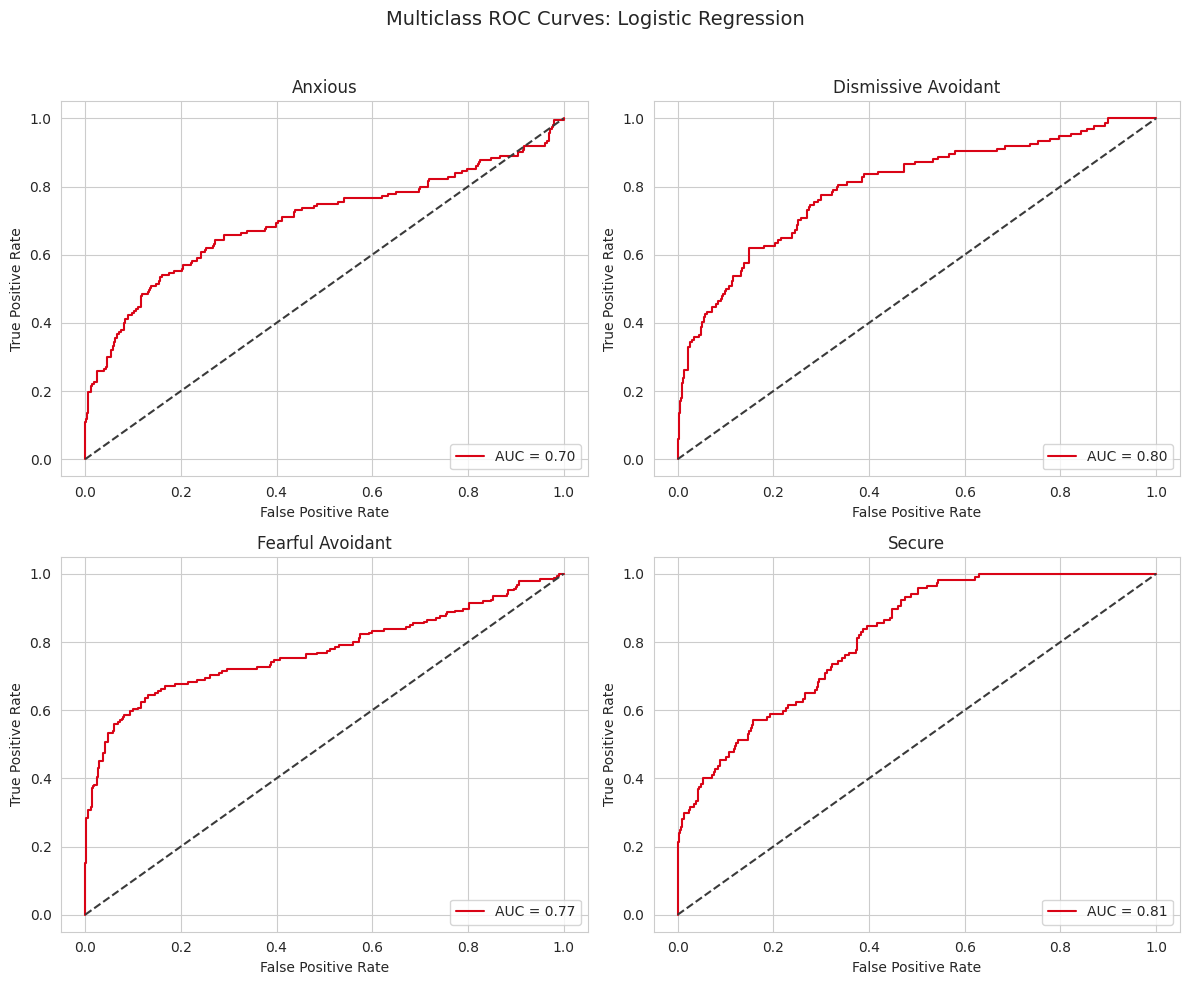



Confusion matrix: Random Forest

[[ 94  26  20  23]
 [ 16  84  14  20]
 [ 21  20 117  28]
 [ 23  20  18  56]]


Classification report: Random Forest

              precision    recall  f1-score   support

           0       0.61      0.58      0.59       163
           1       0.56      0.63      0.59       134
           2       0.69      0.63      0.66       186
           3       0.44      0.48      0.46       117

    accuracy                           0.58       600
   macro avg       0.58      0.58      0.58       600
weighted avg       0.59      0.58      0.59       600

AUC (multiclass, macro) Random Forest: 0.83551


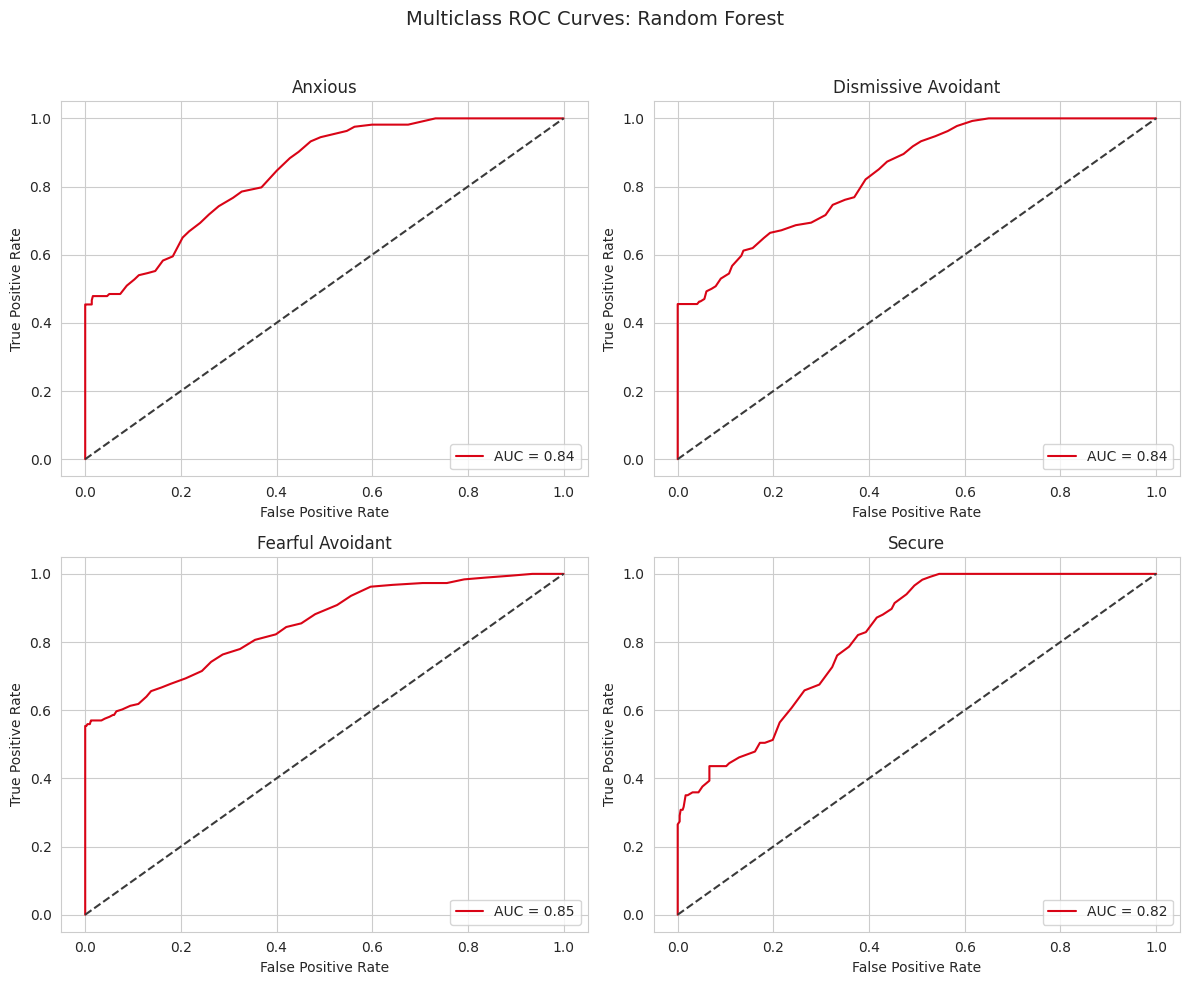



Confusion matrix: XGBoost

[[ 90  28  27  18]
 [ 13  77  18  26]
 [ 31  23 114  18]
 [ 14  29  16  58]]


Classification report: XGBoost

              precision    recall  f1-score   support

           0       0.61      0.55      0.58       163
           1       0.49      0.57      0.53       134
           2       0.65      0.61      0.63       186
           3       0.48      0.50      0.49       117

    accuracy                           0.56       600
   macro avg       0.56      0.56      0.56       600
weighted avg       0.57      0.56      0.57       600

AUC (multiclass, macro) XGBoost: 0.83461


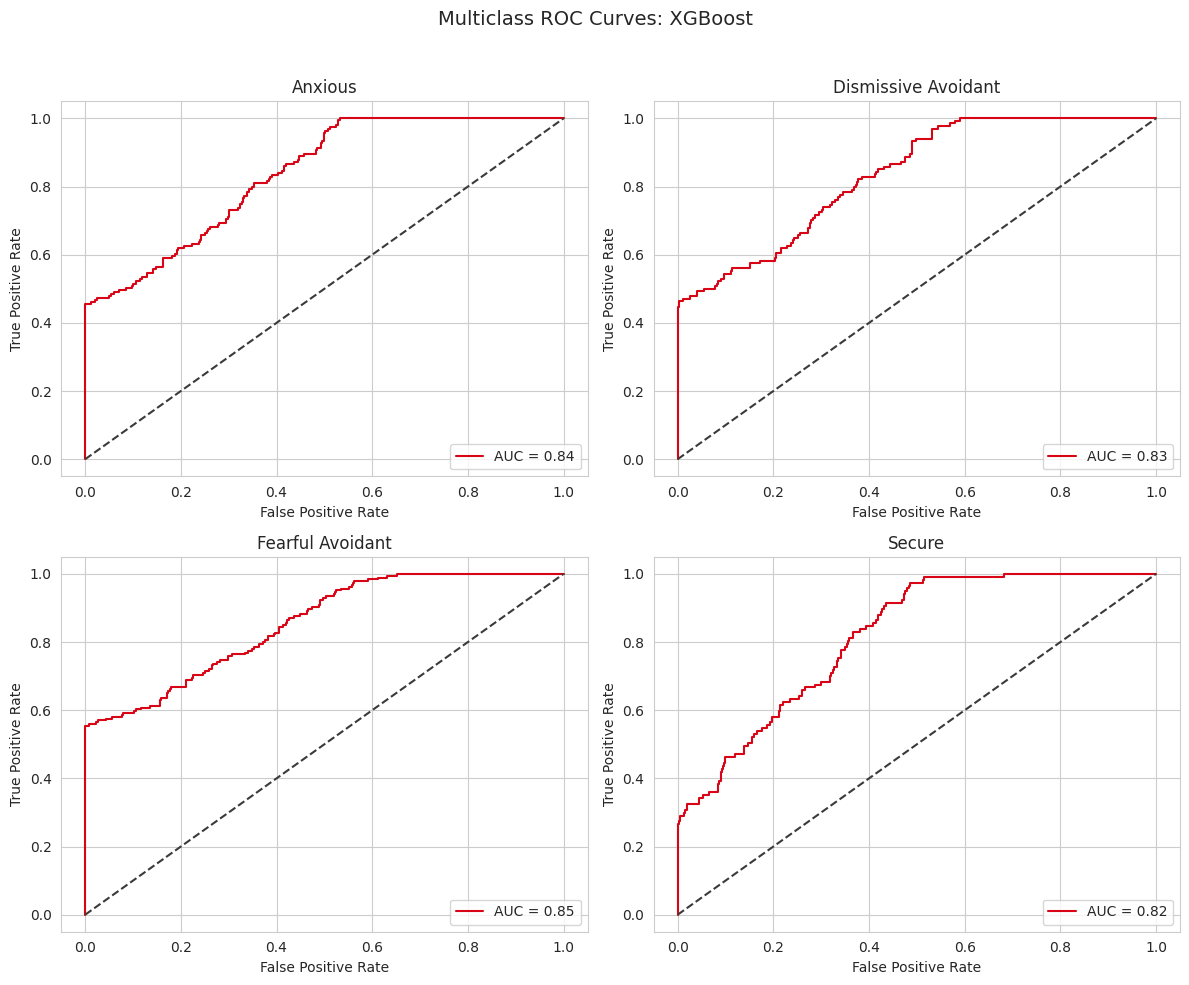

In [21]:
#fit the models

fitted_models = {}

class_labels = {
    0: 'Anxious',
    1: 'Dismissive Avoidant',
    2: 'Fearful Avoidant',
    3: 'Secure'}

for name, pipe in model_pipelines.items():
    
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    
    y_pred = pipe.predict(X_test)
    
    #get predicted probabilities
    y_prob = pipe.predict_proba(X_test)

    #binarize target
    classes = sorted(y.unique())
    y_test_bin = label_binarize(y_test, classes = classes)

    #compute AUC
    auc_score = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class = 'ovr',   
    average = 'macro')
    
    print('\n')
    print('\033[1m' + f'Confusion matrix: {name}\n')
    print(confusion_matrix(y_test, y_pred))
    
    print('\n')
    print('\033[1m' + f'Classification report: {name}\n')
    print(classification_report(y_test, y_pred))
    
    #this AUC/ROC score lets us compare model performance between models. It treats each class as 'one vs rest'
    #and averages performance across all classes giving us one comparable number per model
    print(f"AUC (multiclass, macro) {name}: {round(auc_score, 5)}")
    
    
    # we will also create charts showing the ROC curve but this version compares how well the model 
    #classifies each of the four classes. It gives one ROC curve per attachment style letting us see 
    #which class is harder to predict
    
    # create 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize = (12, 10))
    axes = axes.flatten()

    for i, class_label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        
        ax = axes[i]
        ax.plot(fpr, tpr, label = f'AUC = {roc_auc:.2f}', color = '#D90416')
        ax.plot([0, 1], [0, 1], linestyle = '--', color = '#3A3A3A')
        
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(class_labels[class_label])
        ax.legend(loc = 'lower right')
        
    fig.suptitle(f'Multiclass ROC Curves: {name}', fontsize = 14)
    plt.tight_layout(rect = [0, 0, 1, 0.96])
    plt.show()

# Insights From Model Training

**The Logistic Regression model performed worst overall with precision, recall and F1 scores mainly hovering around the 50-60% mark. The multiclass AUC at 77% was a relatively robust score but the ROC curves show that the model struggled to predict attachment styles for anxious types in particular, with predictions being close to random.**

**The Random Forest and XG Boost models had a similar performance although the Random Forest had a very slight edge. Both models had a similar range in terms of precision, recall and F1 scores although the Random Forest slightly outperformed in terms of both the macro average and weighted average F1 scores. The overall AUC score was also ever so slightly higher for the Random Forest model. This improvement suggests that non-linear models are better suited to capturing the interactions and complex relationships present in the dataset.**

**Across all models, Fearful Avoidant (class 2) was the easiest class to predict, achieving the highest recall and F1 scores consistently. In contrast, the Secure class (class 3) was the most difficult to classify, with significantly lower F1 scores. While this can partly be explained by class imbalance (Fearful Avoidants made up 31% of the training data while Secure types made up 20%), this relatively modest imbalance doesn't fully explain the gap in performance.**

**A more likely driver is class separability: Fearful Avoidant types tend to exhibit stronger and more distinct feature patterns, whereas Secure types overlap more with other attachment styles. Improving classification performance for Secure individuals may require either additional features or feature engineering that better captures positive behavioural signals rather than simply the absence of negative ones.**

**Given these results, Random Forest will be taken forward for hyperparameter tuning to further improve performance, particularly in distinguishing between overlapping attachment styles.**

# Hyperparameter Tuning

In [22]:
#set up pipeline for randomized grid search
rf_pipeline = Pipeline([
    ('preprocessing', unscaled_preprocessor),
    ('model', RandomForestClassifier(random_state = 42))
])

#define the variables that will be tuned in the Random Forest model
grid_params = {
    'model__n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 2000],
    'model__max_features': ['sqrt', 'log2', None],  
    'model__max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
    'model__min_samples_split': [2, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 5, 10, 15],
    'model__bootstrap': [True, False]
}

#define cross validation 
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

#fit the models
rf_random = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = grid_params,
    n_iter = 50,
    scoring = 'f1_macro', #use f1 Macro because this is a multi-class classification problem with mild imbalance
    cv = cv,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=None, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=1600; total time=   8.6s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=None, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=1600; total time=   8.3s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=None, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=1600; total time=   8.3s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=None, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=1600; total time=   8.4s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=None, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=1600; total time=   8.5s
[CV] END model__bootstrap=Tr

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__bootstrap': [True, False], 'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,n_iter,50
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [23]:
#find the best parameters and best score
print('Best Parameters: ', rf_random.best_params_)
print('')
print('Best Score: ', rf_random.best_score_)

Best Parameters:  {'model__n_estimators': 1600, 'model__min_samples_split': 15, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 60, 'model__bootstrap': False}

Best Score:  0.5966186718475577


In [24]:
#put the best model into a variable
best_rf = rf_random.best_estimator_

#make predictions on test_set
y_pred_best = best_rf.predict(X_test)

# Evaluating Model on Test Set

Confusion matrix: Best RF Model

[[ 98  33  16  16]
 [ 22  84  16  12]
 [ 33  22 124   7]
 [ 31  21  16  49]]


Classification report: Best RF Model

              precision    recall  f1-score   support

           0       0.53      0.60      0.56       163
           1       0.53      0.63      0.57       134
           2       0.72      0.67      0.69       186
           3       0.58      0.42      0.49       117

    accuracy                           0.59       600
   macro avg       0.59      0.58      0.58       600
weighted avg       0.60      0.59      0.59       600



AUC (multiclass, macro) Best RF Model: 0.80308


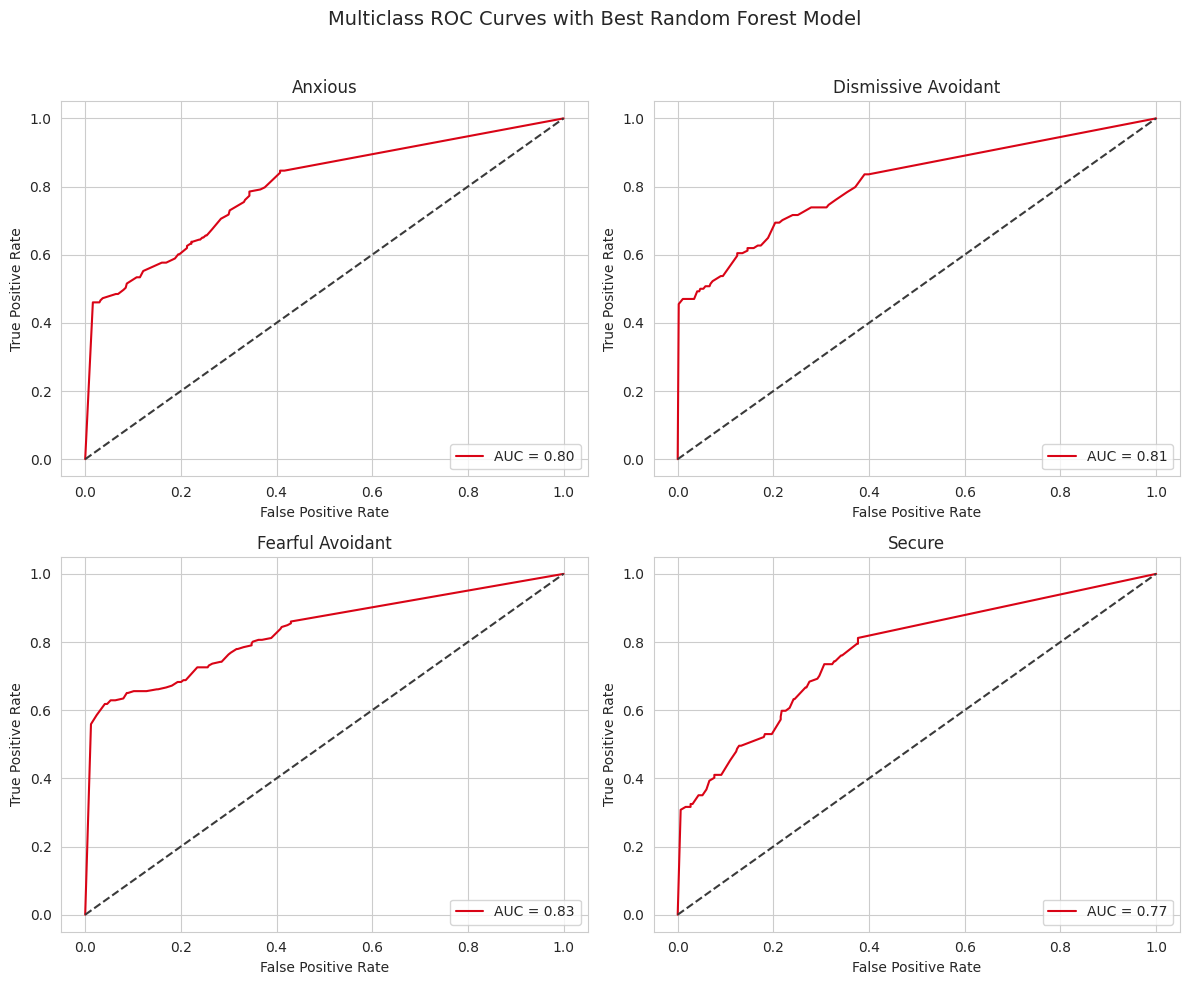

In [25]:
#print confusion matrix
print('\033[1m' + f'Confusion matrix: Best RF Model\n')
print(confusion_matrix(y_test, y_pred_best))

#print classification report
print('\n')
print('\033[1m' + f'Classification report: Best RF Model\n')
print(classification_report(y_test, y_pred_best))

#get predicted probabilities
y_prob = best_rf.predict_proba(X_test)

#binarize target
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes = classes)

#compute AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class = 'ovr', average = 'macro')

print('\n')
print(f"AUC (multiclass, macro) Best RF Model: {round(auc_score, 5)}")

#print ROC curve
#create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
        
    ax = axes[i]
    ax.plot(fpr, tpr, label = f'AUC = {roc_auc:.2f}', color = '#D90416')
    ax.plot([0, 1], [0, 1], linestyle = '--', color = '#3A3A3A')
        
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(class_labels[class_label])
    ax.legend(loc = 'lower right')

fig.suptitle(f'Multiclass ROC Curves with Best Random Forest Model', fontsize = 14)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

In [38]:
#extract feature importance from the pipeline
#first get the model
rf_model = best_rf.named_steps['model']

#get feature names after preprocessing
preprocessor = best_rf.named_steps['preprocessing']

feature_names = preprocessor.get_feature_names_out()

#get importances
importances = rf_model.feature_importances_

#combine into dataframe
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by = 'importance', ascending = False)

In [42]:
# remove transformer prefixes
feature_importances['feature'] = (feature_importances['feature'].str.replace('num__', '', regex = False)\
    .str.replace('cat__', '', regex = False))

In [43]:
# recover original feature names for chart
feature_importances['original_feature'] = feature_importances['feature'].str.replace(r'_[A-Z].*$', '', regex = True)

In [45]:
#aggregate importances back to original feature level
grouped_importance = (feature_importances.groupby('original_feature', as_index = False)['importance'].sum().sort_values\
                      (by = 'importance', ascending = False))

In [88]:
#now looking at permutation importance - this tells us which features actually drive predictions. The regular model feature importance
#just tells you which features the model happened to split on. 
#Permutation measures model performance (the baseline), picks a feature and shuffles it so it breaks its relationship with the target.
#Then it measures performance again to see how much performance drops. If there's a big drop in performance, the model depended heavily
#on that feature
result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

In [89]:
#create a dataframe
perm_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by = 'importance_mean', ascending = False)

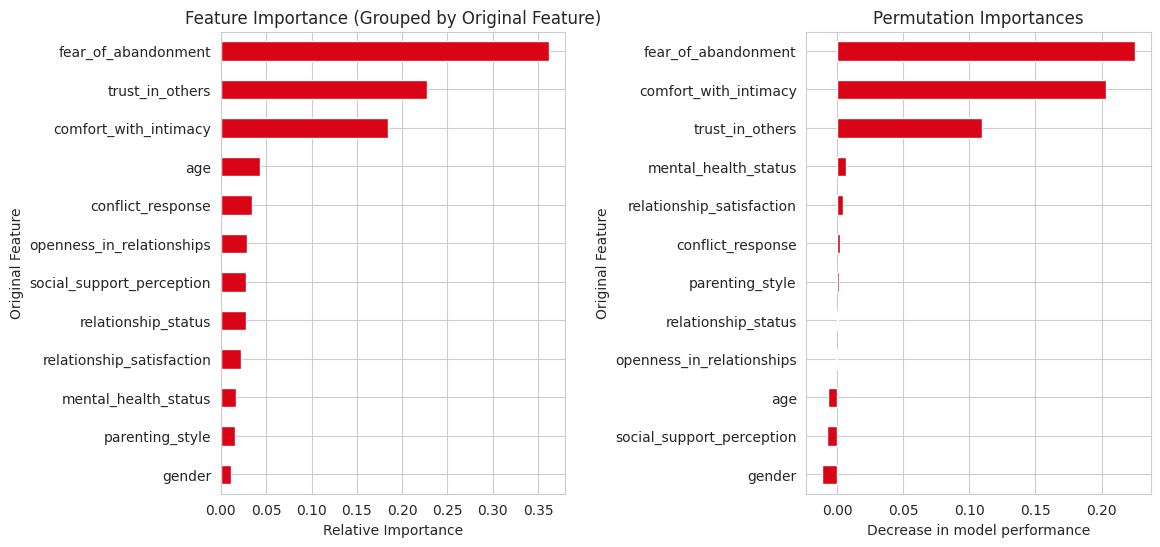

In [97]:
#plot the charts
#the random forest feature importance chart shows normalised importance scores. They sum t0 1 across all features
#the permutation chart shows the absolute drop in model score when the feature is shuffled, e.g if model performance drops by 0.22 
#this means 22 percentage points when this feature is shuffled. The negative permutation features show shuffling the feature slightly 
#improved performance → i.e. the feature is noise / redundant

plt.figure(figsize = (12, 6))

#plot model feature importance
ax = plt.subplot(1, 2, 1)
grouped_importance.set_index('original_feature')['importance'].plot(kind = 'barh', color = '#D90416')
plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.ylabel('Original Feature')
plt.title('Feature Importance (Grouped by Original Feature)')

#plot permutation feature importance
ax = plt.subplot(1, 2, 2)
perm_importance.set_index('feature')['importance_mean'].plot(kind = 'barh', color = '#D90416')

plt.gca().invert_yaxis()
plt.xlabel('Decrease in model performance')
plt.ylabel('Original Feature')
plt.title('Permutation Importances')

plt.subplots_adjust(wspace = 0.7)

plt.show()

In [57]:
#will draw out the final confusion matrix for slide deck - first get the data labels

best_matrix = confusion_matrix(y_test, y_pred_best)

#flatten puts the array values into one row
counts = ['{:,}'.format(value) for value in best_matrix.flatten()]
percentages = ['{0:.1%}'.format(value) for value in best_matrix.flatten() / np.sum(best_matrix)]

#the below attaches the above information together
labels = [f'{a} \n {b}' for a, b, in zip(counts, percentages)]

#converting the above into an array
labels_array = np.asarray(labels).reshape(4, 4)

In [72]:
#stats to display below the matrix

#overall / macro metrics for multiclass model
accuracy = np.trace(best_matrix) / np.sum(best_matrix)

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred_best, average = 'macro')

text = (
    '\n\nAccuracy = {:0.3f}'
    '\nMacro precision = {:0.3f}'
    '\nMacro recall = {:0.3f}'
    '\nMacro F1 score = {:0.3f}'
).format(accuracy, precision, recall, f1_score)

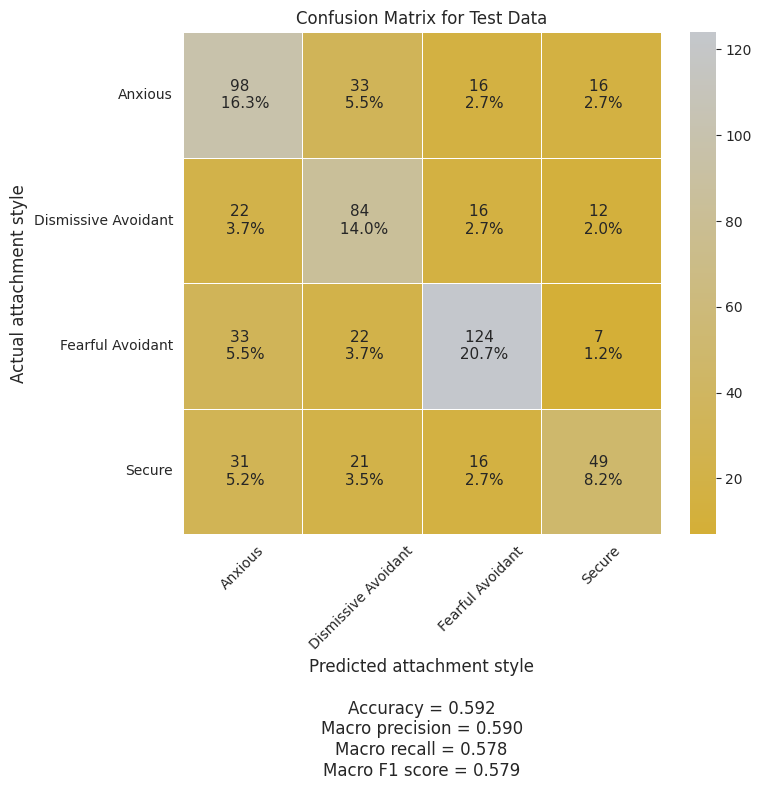

In [75]:
# class labels
class_labels = ['Anxious', 'Dismissive Avoidant', 'Fearful Avoidant', 'Secure']

#create plot
fig = plt.figure(figsize = (8, 8))
ax = plt.subplot()

matrix_colours = ['#D4AF37', '#C4C7CC']
matrix_cmap = LinearSegmentedColormap.from_list('Custom', matrix_colours, N = 256)

sns.heatmap(best_matrix, annot = labels_array, fmt = '', cmap = matrix_cmap, cbar = True, linewidths = 0.5, linecolor = 'white',\
annot_kws = {'size': 11})

ax.set_xlabel('Predicted attachment style' + text, fontsize = 12)
ax.set_ylabel('Actual attachment style', fontsize = 12)

ax.set_xticklabels(class_labels, rotation = 45)
ax.set_yticklabels(class_labels, rotation = 0)

ax.set_title('Confusion Matrix for Test Data', fontsize = 12)

plt.tight_layout()
plt.show()

# Insights From Final Model

**Hyperparameter tuning of the Random Forest model resulted in only a marginal improvement in overall performance. Accuracy increased slightly from 0.58 to 0.59, with small gains in macro and weighted F1 scores. However, the multiclass AUC decreased from 0.84 to 0.80, suggesting that while classification at the chosen threshold improved slightly, the model’s overall ability to rank class probabilities deteriorated.**

**At a class level, performance shifts were mixed. The Fearful Avoidant class (class 2) saw the most notable improvement, with precision increasing from 0.69 to 0.72 and F1 score rising to 0.69. In contrast, the Secure class (class 3) experienced a decline in recall (from 0.48 to 0.42), reinforcing that this remains the most difficult class to correctly identify. Performance for Anxious (class 0) and Dismissive Avoidant (class 1) remained broadly stable.**

**The confusion matrix highlights that misclassification patterns persist despite tuning. There is still significant overlap between adjacent attachment styles, particularly between Anxious and Fearful Avoidant, and between Secure and other classes. This indicates that the model is constrained less by parameter choice and more by feature separability within the dataset.**

**Feature importance and permutation analysis show a highly consistent structure before and after tuning. The model continues to rely heavily on a small set of psychological variables - particularly fear of abandonment, comfort with intimacy, and trust in others - which dominate predictive power. Other features such as demographics and contextual variables contribute minimally, and in some cases appear to add little real predictive value.**

**Overall, the limited gains from hyperparameter tuning suggest that the model is approaching its performance ceiling given the current feature set. Further improvements are more likely to come from feature engineering or additional data - particularly features that better capture positive and stable relationship behaviours - rather than further model optimisation.**

In [99]:
#saving the model - wb means writeback
filename = 'attachment_style.sav'
pickle.dump(best_rf, open(filename, 'wb'))